In [4]:
import pandas as pd
import sys
sys.path.append("..")

from image_to_vector import evaluation_research
from image_to_vector.evaluation_research import (
    load_data, run_similarity_search,
    inference_vanilla, inference_threshold, inference_top_n_softmax,
    evaluate
)

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
pt_species = pd.read_csv("../data/PT_species.csv")

In [6]:
import json
with open("../data/bioclip2_plantnet300k_metadata.json", "r") as f:
    metadata = json.load(f)

In [7]:
dataset_species = set([el["latin_name"].replace("_", " ") for el in metadata])

In [8]:
len(dataset_species)

1019

In [9]:
pt_species["species"].nunique()

12017

In [10]:
(pt_species["species"].drop_duplicates().isin(dataset_species)).value_counts()

species
False    11622
True       396
Name: count, dtype: int64

In [11]:
pd.Series(list(dataset_species)).isin(pt_species["species"]).value_counts()

False    623
True     396
Name: count, dtype: int64

In [12]:
# img_index = "../data/bioclip2_plantnet300k.index"
# img_meta = "../data/bioclip2_plantnet300k_metadata.json"
# text_index = "../data/bioclip2_text_v1.index"
# text_labels = "../data/bioclip2_text_v1_labels.json"
# taxa = "../data/taxa.parquet"
#
# img_vecs_v1_pt, metas_v1_pt, text_idx_v1_pt, labels_v1_pt, taxa_df_v1_pt = load_data(img_index, img_meta, text_index, text_labels, taxa, filter_by_classes=pt_species["species"].to_list(), )
# scores_v1_pt, indices_v1_pt = run_similarity_search(img_vecs_v1_pt, text_idx_v1_pt, k=5)
#
# img_vecs_v1_pn, metas_v1_pn, text_idx_v1_pn, labels_v1_pn, taxa_df_v1_pn = load_data(img_index, img_meta, text_index, text_labels, taxa, filter_by_classes=list(dataset_species), )
# scores_v1_pn, indices_v1_pn = run_similarity_search(img_vecs_v1_pn, text_idx_v1_pn, k=5)
#
# img_vecs_v1_all, metas_v1_all, text_idx_v1_all, labels_v1_all, taxa_df_v1_all = load_data(img_index, img_meta, text_index, text_labels, taxa, filter_by_classes=None, )
# scores_v1_all, indices_v1_all = run_similarity_search(img_vecs_v1_all, text_idx_v1_all, k=5)

# 1. Load Everything
img_index = "../data/bioclip2_plantnet300k.index"
img_meta = "../data/bioclip2_plantnet300k_metadata.json"
text_index = "../data/bioclip2_text_v2.index"
text_labels = "../data/bioclip2_text_v2_labels.json"
taxa = "../data/taxa.parquet"

# img_vecs_v2_pt, metas_v2_pt, text_idx_v2_pt, labels_v2_pt, taxa_df_v2_pt = load_data(img_index, img_meta, text_index, text_labels, taxa, filter_by_classes=pt_species["species"].to_list(), )
# scores_v2_pt, indices_v2_pt = run_similarity_search(img_vecs_v2_pt, text_idx_v2_pt, k=5)

img_vecs_v2_pn, metas_v2_pn, text_idx_v2_pn, labels_v2_pn, taxa_df_v2_pn = load_data(img_index, img_meta, text_index, text_labels, taxa, filter_by_classes=list(dataset_species), )
scores_v2_pn, indices_v2_pn = run_similarity_search(img_vecs_v2_pn, text_idx_v2_pn, k=5)

img_vecs_v2_all, metas_v2_all, text_idx_v2_all, labels_v2_all, taxa_df_v2_all = load_data(img_index, img_meta, text_index, text_labels, taxa, filter_by_classes=None, )
scores_v2_all, indices_v2_all = run_similarity_search(img_vecs_v2_all, text_idx_v2_all, k=5)

Loading Image Index: ../data/bioclip2_plantnet300k.index
Loading Image Metadata: ../data/bioclip2_plantnet300k_metadata.json
Loading Text Index: ../data/bioclip2_text_v2.index
Loading Text Labels: ../data/bioclip2_text_v2_labels.json
Filtering text embeddings...
Filtered text index down to 919 vectors.
Loading Taxonomic Data: ../data/taxa.parquet
Running similarity search for top-5 matches...
Loading Image Index: ../data/bioclip2_plantnet300k.index
Loading Image Metadata: ../data/bioclip2_plantnet300k_metadata.json
Loading Text Index: ../data/bioclip2_text_v2.index
Loading Text Labels: ../data/bioclip2_text_v2_labels.json
Loading Taxonomic Data: ../data/taxa.parquet
Running similarity search for top-5 matches...


In [13]:
text_idx_v2_all.ntotal

393714

In [13]:
preds_v1_all = inference_vanilla(scores_v1_all, indices_v1_all, labels_v1_all, taxa_df_v1_all)
summary, details = evaluate(preds_v1_all, metas_v1_all, taxa_df_v1_all, split_filter=['train', 'val', 'test'])
display(summary)

NameError: name 'scores_v1_all' is not defined

In [14]:
preds_v2_all = inference_vanilla(scores_v2_all, indices_v2_all, labels_v2_all, taxa_df_v2_all)
summary, details = evaluate(preds_v2_all, metas_v2_all, taxa_df_v2_all, split_filter=['train', 'val', 'test'])
display(summary)

,Count,Species Accuracy,Species Coverage,Genus Accuracy,Family Accuracy,Order Accuracy,Class Accuracy
Split,,,,,,,
test,31112,0.603754,1.0,0.861748,0.942882,0.949838,0.991645
train,243916,0.606455,1.0,0.862667,0.944599,0.950358,0.991878
val,31118,0.603863,1.0,0.859803,0.943746,0.949644,0.991852


In [15]:
details.groupby("gt_family").agg(
    species_match=("species_match", "mean"),
    genus_match=("genus_match", "mean"),
    family_match=("family_match", "mean"),
    samples_count=("gt_family", "size"),
)


,species_match,genus_match,family_match,samples_count
gt_family,,,,
Acanthaceae,0.454171,0.607621,0.750772,1942
Aextoxicaceae,0.714286,0.714286,0.714286,7
Aizoaceae,0.082822,0.846626,0.877301,326
Alismataceae,0.611354,0.855895,0.912664,229
Amaranthaceae,0.504505,0.711712,0.774775,111
...,...,...,...,...
Turneraceae,0.166667,0.166667,0.666667,6
Urticaceae,0.454545,0.681818,0.772727,22
Vitaceae,0.086957,0.76087,0.76087,46


In [18]:
res = details.groupby("gt_family").agg(
    species_match=("species_match", "mean"),
    genus_match=("genus_match", "mean"),
    family_match=("family_match", "mean"),
    samples_count=("gt_family", "size"),
).sort_values("samples_count", ascending=False)
res.head(20)


,species_match,genus_match,family_match,samples_count
gt_family,,,,
Asteraceae,0.711239,0.840447,0.970692,41491
Fabaceae,0.722215,0.936166,0.974759,29476
Lamiaceae,0.756012,0.928837,0.965068,22329
Apiaceae,0.707381,0.797279,0.960984,17275
Crassulaceae,0.344399,0.801299,0.948022,16507
Hypericaceae,0.648590,0.962987,0.963919,13941
Ranunculaceae,0.556297,0.881075,0.952402,11093
Brassicaceae,0.871850,0.950913,0.983888,10675
Papaveraceae,0.676571,0.936663,0.951422,10231


In [40]:
res.loc["Butomaceae"]

species_match    0.936842
genus_match      0.942105
family_match     0.942105
samples_count         380
Name: Butomaceae, dtype: object

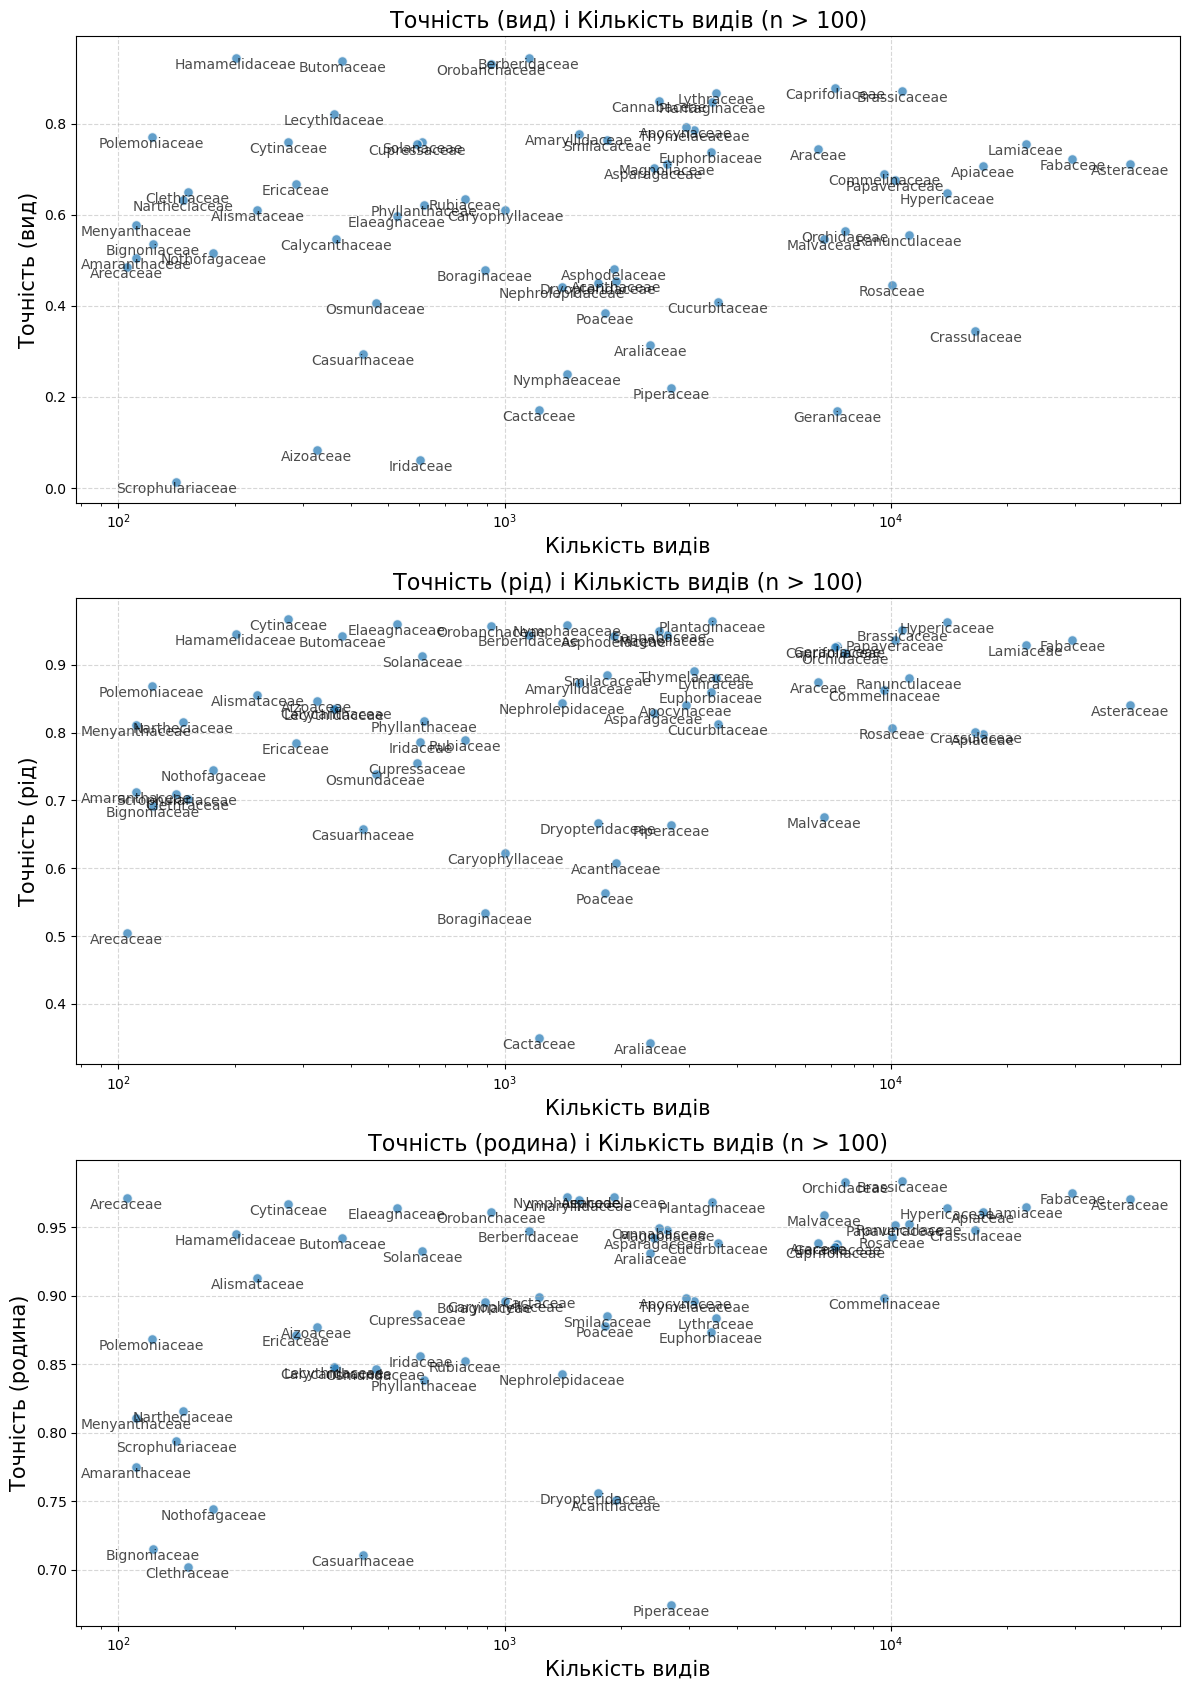

In [37]:
import matplotlib.pyplot as plt

# 1. Filter the DataFrame for samples_count > 100
df_filtered = res[res['samples_count'] > 100]
df_filtered = df_filtered.rename(columns={
    "samples_count": "Кількість видів",
    "species_match": "Точність (вид)",
    "genus_match": "Точність (рід)",
    "family_match": "Точність (родина)",
})

# 2. Define the y-axis columns
y_columns = ["Точність (вид)", "Точність (рід)", "Точність (родина)"]

# 3. Create a figure with 3 separate subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 17))

for ax, y_col in zip(axes, y_columns):
    # Create the scatter plot
    ax.scatter(df_filtered["Кількість видів"], df_filtered[y_col], alpha=0.7, edgecolors='w', s=50)
    
    # Add text labels for each point (from the index 'gt_family')
    for idx, row in df_filtered.iterrows():
        ax.text(
            x=row["Кількість видів"], 
            y=row[y_col], 
            s=str(idx), 
            fontsize=10,
            ha='center',      # Horizontal alignment
            va='top',     # Vertical alignment
            alpha=0.7
        )
        
    # Formatting the plot
    ax.set_title(f"{y_col} і Кількість видів (n > 100)", fontsize=16)
    ax.set_xlabel("Кількість видів", fontsize=15)
    ax.set_ylabel(y_col, fontsize=15)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xscale('log')

# Adjust layout so plots and labels don't overlap
plt.tight_layout()
plt.show()

In [ ]:
preds_v1_pt = inference_vanilla(scores_v1_pt, indices_v1_pt, labels_v1_pt, taxa_df_v1_pt)
summary, details = evaluate(preds_v1_pt, metas_v1_pt, taxa_df_v1_pt, split_filter=['train', 'val', 'test'])
display(summary)

In [12]:
preds_v2_pt = inference_vanilla(scores_v2_pt, indices_v2_pt, labels_v2_pt, taxa_df_v2_pt)
summary, details = evaluate(preds_v2_pt, metas_v2_pt, taxa_df_v2_pt, split_filter=['train', 'val', 'test'])
display(summary)

,Count,Species Accuracy,Species Coverage,Genus Accuracy,Family Accuracy,Order Accuracy,Class Accuracy
Split,,,,,,,
test,31112,0.614200,1.0,0.832324,0.919488,0.927502,0.982097
train,243916,0.619369,1.0,0.835470,0.921492,0.928546,0.981904
val,31118,0.612154,1.0,0.831489,0.920119,0.928676,0.981726


In [13]:
preds_v1_pn = inference_vanilla(scores_v1_pn, indices_v1_pn, labels_v1_pn, taxa_df_v1_pn)
summary, details = evaluate(preds_v1_pn, metas_v1_pn, taxa_df_v1_pn, split_filter=['train', 'val', 'test'])
display(summary)

,Count,Species Accuracy,Species Coverage,Genus Accuracy,Family Accuracy,Order Accuracy,Class Accuracy
Split,,,,,,,
test,31112,0.647467,1.0,0.922782,0.950793,0.954714,0.986871
train,243916,0.651823,1.0,0.926920,0.953096,0.956524,0.986984
val,31118,0.647921,1.0,0.926331,0.953837,0.957076,0.987181


In [14]:
preds_v2_pn = inference_vanilla(scores_v2_pn, indices_v2_pn, labels_v2_pn, taxa_df_v2_pn)
summary, details = evaluate(preds_v2_pn, metas_v2_pn, taxa_df_v2_pn, split_filter=['train', 'val', 'test'])
display(summary)

,Count,Species Accuracy,Species Coverage,Genus Accuracy,Family Accuracy,Order Accuracy,Class Accuracy
Split,,,,,,,
test,31112,0.743507,1.0,0.954813,0.970503,0.972856,0.994987
train,243916,0.747212,1.0,0.956240,0.971865,0.973886,0.994837
val,31118,0.745421,1.0,0.954656,0.971123,0.973168,0.994477


In [17]:
import evaluation_research
import importlib
importlib.reload(evaluation_research)
from evaluation_research import load_data, run_similarity_search, inference_vanilla, evaluate

In [18]:
img_vecs_v2_all, metas_v2_all, text_idx_v2_all, labels_v2_all, taxa_df_v2_all = load_data(img_index, img_meta, text_index, text_labels, taxa, filter_by_classes=None, split_filter=["train"])

Loading Image Index: ../data/bioclip2_plantnet300k.index
Loading Image Metadata: ../data/bioclip2_plantnet300k_metadata.json
Loading Text Index: ../data/bioclip2_text_v2.index
Loading Text Labels: ../data/bioclip2_text_v2_labels.json
Loading Taxonomic Data: ../data/taxa.parquet


In [28]:
stat = pd.DataFrame(metas_v2_all)
stat["species"] = stat["latin_name"].apply(lambda x: x.replace("_", " "))
stat = stat.merge(taxa_df_v2_all, how="left", left_on="species", right_on="species")

In [29]:
stat

,filename,split,class_id,latin_name,image_path,species,kingdom,phylum,class,order,family,genus,common_name,present_in_taxa,present_in_TOL
0,8d5066818d2fc73b454188e0a382493736f8c3a5,train,1369887,Trachelospermum_jasminoides,../data/plantnet_300K/images_train/1369887/8d5...,Trachelospermum jasminoides,Plantae,Tracheophyta,Magnoliopsida,Gentianales,Apocynaceae,Trachelospermum,Confederate jasmine,True,True
1,ce869924df8466cc351667f492d823cad5c5f366,train,1392361,Fragaria_moschata,../data/plantnet_300K/images_train/1392361/ce8...,Fragaria moschata,Plantae,Tracheophyta,Magnoliopsida,Rosales,Rosaceae,Fragaria,Hautbois Strawberry,True,True
2,5e4e9254e791d5f6f3975ccd4e4b01fcbd439b86,train,1393965,Noccaea_caerulescens,../data/plantnet_300K/images_train/1393965/5e4...,Noccaea caerulescens,Plantae,Tracheophyta,Magnoliopsida,Brassicales,Brassicaceae,Noccaea,Alpine pennycress,True,True
3,ad3474b4038f9aa31ec1c559fdeef3440a050bc1,train,1355978,Pelargonium_zonale,../data/plantnet_300K/images_train/1355978/ad3...,Pelargonium zonale,Plantae,Tracheophyta,Magnoliopsida,Geraniales,Geraniaceae,Pelargonium,Horseshoe geranium,True,True
4,31d75b075e18d6f40c866cf82d07a90e2ae65b76,train,1438352,Smilax_bona-nox,../data/plantnet_300K/images_train/1438352/31d...,Smilax bona-nox,Plantae,Tracheophyta,Liliopsida,Liliales,Smilacaceae,Smilax,Catbrier,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245675,4835a323be825c5cf6066399594a8575fe0003c4,train,1363737,Trifolium_dubium,../data/plantnet_300K/images_train/1363737/483...,Trifolium dubium,Plantae,Tracheophyta,Magnoliopsida,Fabales,Fabaceae,Trifolium,Lesser Yellow Trefoil,True,True
245676,bc81e380e0056da949663c2a669b19fa98f63758,train,1394591,Angelica_sylvestris,../data/plantnet_300K/images_train/1394591/bc8...,Angelica sylvestris,Plantae,Tracheophyta,Magnoliopsida,Apiales,Apiaceae,Angelica,Wild angelica,True,True
245677,07ad0a7a809b3b15fe017880d856d9e26b9a4940,train,1358133,Sedum_sediforme,../data/plantnet_300K/images_train/1358133/07a...,Sedum sediforme,Plantae,Tracheophyta,Magnoliopsida,Saxifragales,Crassulaceae,None,None,None,False
245678,587f088b3383cdafde8598bc26b4352bf10aad92,train,1413002,Aralia_nudicaulis,../data/plantnet_300K/images_train/1413002/587...,Aralia nudicaulis,Plantae,Tracheophyta,Magnoliopsida,Apiales,Araliaceae,Aralia,Wild sarsaparilla,True,True


In [35]:
stat.groupby("species").size()

species
Abeliophyllum distichum       4
Acacia angustissima           8
Acacia auriculiformis        26
Acacia baileyana             55
Acacia berlandieri            4
                           ... 
Zaleya pentandra              4
Zamia furfuracea             53
Zamia pumila                 17
Zamioculcas zamiifolia     1730
Zannichellia palustris        3
Length: 1019, dtype: int64

ValueError: The number of FixedLocator locations (11), usually from a call to set_ticks, does not match the number of labels (1).

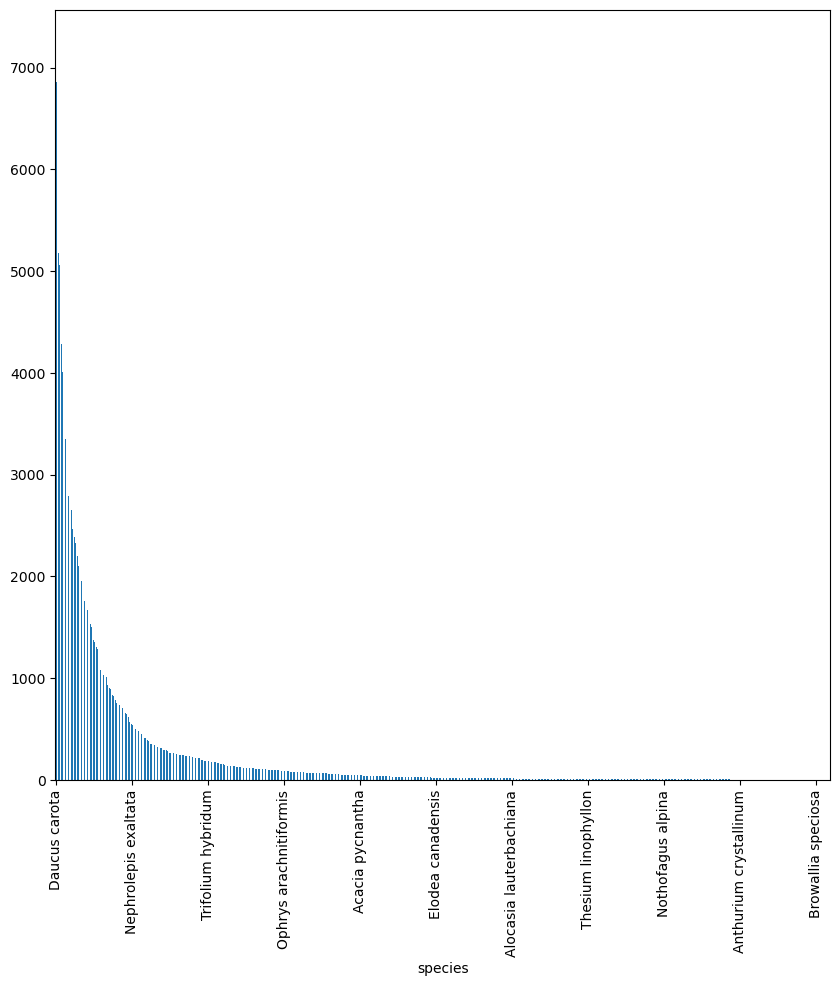

In [39]:
ax = stat.groupby("species").size().sort_values(ascending=False).plot.bar(figsize=(10, 10))
ax.set_xticks(range(0, len(ax.get_xticklabels()), 100))
ax.set_xticklabels([label.get_text() for i, label in enumerate(ax.get_xticklabels()) if i % 100 == 0], rotation=0)
plt.title("")



In [19]:
img_vecs_v2_all.shape

(243916, 768)

In [20]:
scores_v2_all, indices_v2_all = run_similarity_search(img_vecs_v2_all, text_idx_v2_all, k=4)

Running similarity search for top-4 matches...


In [21]:
preds_v2_all = inference_vanilla(scores_v2_all, indices_v2_all, labels_v2_all, taxa_df_v2_all)
summary, details = evaluate(preds_v2_all, metas_v2_all, taxa_df_v2_all, split_filter=['train',])
display(summary)

,Count,Species Accuracy,Species Coverage,Genus Accuracy,Family Accuracy,Order Accuracy,Class Accuracy
Split,,,,,,,
train,243916,0.606455,1.0,0.862667,0.944599,0.950358,0.991878


In [40]:
details["similarity_score"] = scores_v2_all[:, 0]

In [41]:
details["sim_score_decile"] = pd.qcut(details["similarity_score"], q=10, labels=list(range(1,11)))

In [42]:
_, bins = pd.qcut(details["similarity_score"], q=10, labels=list(range(1,11)), retbins=True)

In [43]:
bins_df = pd.DataFrame({"sim_from": bins[:-1], "sim_to": bins[1:]})

In [44]:
pd.merge(details.groupby("sim_score_decile")[["species_match", "genus_match"]].mean().reset_index(), bins_df, how="inner", left_index=True, right_index=True)

/var/folders/9d/h8rbsks17_q094cwz_ynql6c0000gn/T/ipykernel_79300/1776280538.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.merge(details.groupby("sim_score_decile")[["species_match", "genus_match"]].mean().reset_index(), bins_df, how="inner", left_index=True, right_index=True)


,sim_score_decile,species_match,genus_match,sim_from,sim_to
0,1,0.683585,0.810787,0.602381,0.719673
1,2,0.783454,0.89841,0.719673,0.724477
2,3,0.713624,0.869863,0.724477,0.728922
3,4,0.676820,0.87177,0.728922,0.732692
4,5,0.616498,0.864893,0.732692,0.736540
5,6,0.596278,0.866843,0.736540,0.740699
6,7,0.578803,0.86859,0.740699,0.745271
7,8,0.545179,0.87274,0.745271,0.750731
8,9,0.461482,0.854311,0.750731,0.758936
9,10,0.408823,0.84634,0.758936,0.838055


In [45]:
tmp = pd.merge(details.groupby("sim_score_decile")[["species_match", "genus_match"]].mean().reset_index(), bins_df, how="inner", left_index=True, right_index=True)

/var/folders/9d/h8rbsks17_q094cwz_ynql6c0000gn/T/ipykernel_79300/336394043.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = pd.merge(details.groupby("sim_score_decile")[["species_match", "genus_match"]].mean().reset_index(), bins_df, how="inner", left_index=True, right_index=True)


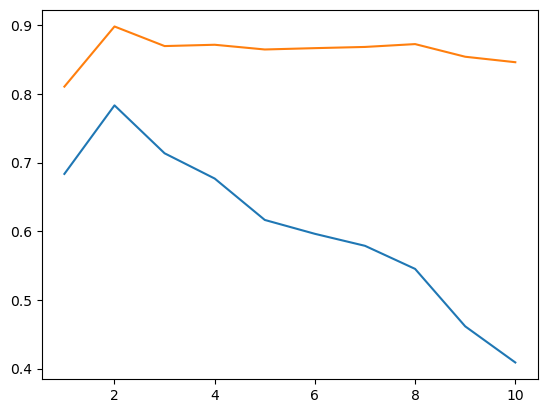

In [48]:
plt.plot(tmp["sim_score_decile"], tmp["species_match"])
plt.plot(tmp["sim_score_decile"], tmp["genus_match"])

In [49]:
details["top-1-diff"] = scores_v2_all[:, 0] - scores_v2_all[:, 1]

In [50]:
details["diff_decile"], bins = pd.qcut(details["top-1-diff"], q=10, labels=list(range(1,11)), retbins=True)

In [51]:
bins_df = pd.DataFrame({"diff_from": bins[:-1], "diff_to": bins[1:]})

In [52]:
pd.merge(details.groupby("diff_decile")[["species_match", "genus_match", "family_match"]].mean().reset_index(), bins_df, how="inner", left_index=True, right_index=True)

/var/folders/9d/h8rbsks17_q094cwz_ynql6c0000gn/T/ipykernel_79300/2222287663.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.merge(details.groupby("diff_decile")[["species_match", "genus_match", "family_match"]].mean().reset_index(), bins_df, how="inner", left_index=True, right_index=True)


,diff_decile,species_match,genus_match,family_match,diff_from,diff_to
0,1,0.205370,0.679149,0.856004,0.000000,0.002357
1,2,0.275780,0.715962,0.875867,0.002357,0.005290
2,3,0.364192,0.756975,0.899687,0.005290,0.008851
3,4,0.486369,0.817119,0.928259,0.008851,0.013170
4,5,0.610701,0.876258,0.955055,0.013170,0.018042
5,6,0.716464,0.913425,0.969428,0.018042,0.023505
6,7,0.784962,0.936421,0.979615,0.023505,0.029807
7,8,0.835281,0.955201,0.986768,0.029807,0.037056
8,9,0.878106,0.965957,0.992087,0.037056,0.045977
9,10,0.907347,0.976541,0.993179,0.045977,0.089433


In [53]:
pd.merge(details.groupby("diff_decile")[["species_match", "genus_match", "family_match"]].mean().reset_index(), bins_df, how="inner", left_index=True, right_index=True).to_csv("../data/top_1_diff_decile.csv", index=False)

/var/folders/9d/h8rbsks17_q094cwz_ynql6c0000gn/T/ipykernel_79300/1483476072.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.merge(details.groupby("diff_decile")[["species_match", "genus_match", "family_match"]].mean().reset_index(), bins_df, how="inner", left_index=True, right_index=True).to_csv("../data/top_1_diff_decile.csv", index=False)


In [54]:
from evaluation_research import inference_margin_threshold

In [107]:
preds_v2_all = inference_margin_threshold(scores_v2_all, indices_v2_all, labels_v2_all, taxa_df_v2_all, margin_threshold=0.013171)

In [108]:
summary, details = evaluate(preds_v2_all, metas_v2_all, taxa_df_v2_all, split_filter=['train', 'val', 'test'])

In [109]:
summary

,Count,Species Accuracy,Species Coverage,Genus Accuracy,Family Accuracy,Order Accuracy,Class Accuracy
Split,,,,,,,
train,243916,0.788819,0.599977,0.862672,0.944599,0.950358,0.991878


In [55]:
indices_correct = indices_v2_all.copy()
for i in range(indices_v2_all.shape[0]):
    correct_class = metas_v2_all[i]["latin_name"].replace("_", " ")
    for j in range(indices_v2_all.shape[1]):
        if labels_v2_all[indices_v2_all[i, j]] == correct_class:
            indices_correct[i, j] = True
        else:
            indices_correct[i, j] = False

In [56]:
indices_correct.sum(axis=0).sum()

179447

In [57]:
indices_correct.sum(axis=0)

array([147924,  18874,   7671,   4978])

In [58]:
mask_top_1 = indices_correct[:, 0].astype(bool)
mask_top_2 = (indices_correct[:, 1] | mask_top_1).astype(bool)
mask_top_3 = (indices_correct[:, 2] | mask_top_2).astype(bool)

In [59]:
sum(mask_top_1), sum(mask_top_2), sum(mask_top_3)

(147924, 166798, 174469)

In [60]:
abs_diff_1 = scores_v2_all[:, 0] - scores_v2_all[:, 1]
abs_diff_2 = scores_v2_all[:, 1] - scores_v2_all[:, 2]
abs_diff_3 = scores_v2_all[:, 2] - scores_v2_all[:, 3]

In [61]:
sm_diff_1 = sm[:, :1].sum(axis=1)
sm_diff_2 = sm[:, :2].sum(axis=1)
sm_diff_3 = sm[:, :3].sum(axis=1)

NameError: name 'sm' is not defined

In [62]:
sm_diff1_dec, bins = pd.qcut(abs_diff_1, q=10, labels=list(range(1,11)), retbins=True)
bins_df = pd.DataFrame({"sm_diff1_from": bins[:-1], "sm_diff1_to": bins[1:]})
res = pd.DataFrame({"sm_diff_1": abs_diff_1, "sm_diff1_dec": sm_diff1_dec, "top1": mask_top_1})
res = pd.merge(res.groupby("sm_diff1_dec")["top1"].mean().reset_index(), bins_df, how="inner", left_index=True, right_index=True)
res["top1_cumsum"] = res.sort_values("sm_diff1_from", ascending=False)["top1"].cumsum()
res["acc_cumcum"] = res["top1_cumsum"] / res["sm_diff1_dec"].sort_values(ascending=False).reset_index(drop=True).astype(float)

/var/folders/9d/h8rbsks17_q094cwz_ynql6c0000gn/T/ipykernel_79300/3409288980.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res = pd.merge(res.groupby("sm_diff1_dec")["top1"].mean().reset_index(), bins_df, how="inner", left_index=True, right_index=True)


In [63]:
res

,sm_diff1_dec,top1,sm_diff1_from,sm_diff1_to,top1_cumsum,acc_cumcum
0,1,0.205370,0.000000,0.002357,6.064571,0.606457
1,2,0.275780,0.002357,0.005290,5.859201,0.651022
2,3,0.364192,0.005290,0.008851,5.583421,0.697928
3,4,0.486369,0.008851,0.013170,5.219229,0.745604
4,5,0.610701,0.013170,0.018042,4.732860,0.788810
5,6,0.716464,0.018042,0.023505,4.122159,0.824432
6,7,0.784962,0.023505,0.029807,3.405695,0.851424
7,8,0.835281,0.029807,0.037056,2.620733,0.873578
8,9,0.878106,0.037056,0.045977,1.785452,0.892726
9,10,0.907347,0.045977,0.089433,0.907347,0.907347


In [146]:
sm_diff1_dec, bins = pd.qcut(abs_diff_3, q=10, labels=list(range(1,11)), retbins=True)
bins_df = pd.DataFrame({"diff_from": bins[:-1], "diff_to": bins[1:]})
res = pd.DataFrame({"sm_diff_1": abs_diff_3, "diff_decile": sm_diff1_dec, "species_match_top-3": mask_top_3})
res = pd.merge(res.groupby("diff_decile")["species_match_top-3"].mean().reset_index(), bins_df, how="inner", left_index=True, right_index=True)
res["top1_cumsum"] = res.sort_values("diff_from", ascending=False)["species_match_top-3"].cumsum()
res["acc_cumcum"] = res["top1_cumsum"] / res["diff_decile"].sort_values(ascending=False).reset_index(drop=True).astype(float)

res

/var/folders/9d/h8rbsks17_q094cwz_ynql6c0000gn/T/ipykernel_1889/3428355391.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res = pd.merge(res.groupby("diff_decile")["species_match_top-3"].mean().reset_index(), bins_df, how="inner", left_index=True, right_index=True)


,diff_decile,species_match_top-3,diff_from,diff_to,top1_cumsum,acc_cumcum
0,1,0.664371,5.960464e-08,0.000441,7.152834,0.715283
1,2,0.676820,4.405379e-04,0.000932,6.488463,0.720940
2,3,0.686347,9.316802e-04,0.001489,5.811643,0.726455
3,4,0.699697,1.488715e-03,0.002136,5.125296,0.732185
4,5,0.705805,2.135754e-03,0.002907,4.425599,0.737600
5,6,0.723833,2.906919e-03,0.003844,3.719794,0.743959
6,7,0.730843,3.844500e-03,0.005050,2.995961,0.748990
7,8,0.749754,5.049884e-03,0.006781,2.265118,0.755039
8,9,0.759460,6.781220e-03,0.009751,1.515364,0.757682
9,10,0.755904,9.750754e-03,0.056445,0.755904,0.755904


In [148]:
res[["diff_decile", "species_match_top-3", "diff_from", "diff_to",]].to_csv("../data/top_3_diff_decile.csv", index=False)